In [3]:
import networkx as nx
import pandas as pd # version 2.3.1
import geopandas as gpd #1.0.1
import numpy as np # 2.2.6
import shapely   # 2.0.7 , measure importance of features through SHAP values
import os
import skmob
import dropbox
import os
from dotenv import load_dotenv 
from dropbox import DropboxOAuth2FlowNoRedirect

In [6]:
def authorize():
    load_dotenv()
    APP_KEY = os.environ.get("DROPBOX_APP_KEY")
    APP_SECRET = os.environ.get("DROPBOX_APP_SECRET")

    auth_flow = DropboxOAuth2FlowNoRedirect(APP_KEY,
                                            use_pkce = True,
                                            consumer_secret=APP_SECRET,
                                            token_access_type='offline',
                                            scope=['files.content.read'])

    authorize_url = auth_flow.start()
    print("1. Go to: " + authorize_url)
    print("2. Click \"Allow\" (you might have to log in first).")
    print("3. Copy the authorization code.")
    auth_code = input("Enter the authorization code here: ").strip()

    try:
        oauth_result = auth_flow.finish(auth_code)
        assert oauth_result.scope == 'files.content.read'
    except Exception as e:
        print('Error: %s' % (e,))
        exit(1)

    with dropbox.Dropbox(oauth2_access_token=oauth_result.access_token,
                        oauth2_access_token_expiration=oauth_result.expires_at,
                        oauth2_refresh_token=oauth_result.refresh_token,
                        app_key=APP_KEY,
                        app_secret=APP_SECRET):
        print("Successfully set up client!")

In [5]:
dbx = authorize()

1. Go to: https://www.dropbox.com/oauth2/authorize?response_type=code&client_id=vbt4c90yghbwqpt&token_access_type=offline&code_challenge=awj4m_J9cO8V0CyYgGhi33MZc5Rt3Kdn1TM9SJJt8lA&code_challenge_method=S256&scope=files.content.read
2. Click "Allow" (you might have to log in first).
3. Copy the authorization code.
Error: 400 Client Error: Bad Request for url: https://api.dropboxapi.com/oauth2/token


UnboundLocalError: local variable 'oauth_result' referenced before assignment

In [7]:
load_dotenv()
APP_KEY = os.environ.get("DROPBOX_APP_KEY")
APP_SECRET = os.environ.get("DROPBOX_APP_SECRET")

auth_flow = DropboxOAuth2FlowNoRedirect(APP_KEY,
                                        use_pkce = True,
                                        consumer_secret=APP_SECRET,
                                        token_access_type='offline',
                                        scope=['files.content.read'])

authorize_url = auth_flow.start()
print("1. Go to: " + authorize_url)
print("2. Click \"Allow\" (you might have to log in first).")
print("3. Copy the authorization code.")
auth_code = input("Enter the authorization code here: ").strip()

try:
    oauth_result = auth_flow.finish(auth_code)
    assert oauth_result.scope == 'files.content.read'
except Exception as e:
    print('Error: %s' % (e,))
    exit(1)

with dropbox.Dropbox(oauth2_access_token=oauth_result.access_token,
                    oauth2_access_token_expiration=oauth_result.expires_at,
                    oauth2_refresh_token=oauth_result.refresh_token,
                    app_key=APP_KEY,
                    app_secret=APP_SECRET):
    print("Successfully set up client!")

1. Go to: https://www.dropbox.com/oauth2/authorize?response_type=code&client_id=vbt4c90yghbwqpt&token_access_type=offline&code_challenge=l-y4SsITqKbzJ6qXh6cr3RlT4MGxmJwn9NC4SqQ2Wts&code_challenge_method=S256&scope=files.content.read
2. Click "Allow" (you might have to log in first).
3. Copy the authorization code.
Error: 
Successfully set up client!


In [8]:
dbx = dropbox.Dropbox(oauth2_access_token=oauth_result.access_token,
                    oauth2_access_token_expiration=oauth_result.expires_at,
                    oauth2_refresh_token=oauth_result.refresh_token,
                    app_key=APP_KEY,
                    app_secret=APP_SECRET)

In [11]:
from io import BytesIO

In [9]:
def load_data(dbx: dropbox.Dropbox, data_folder_path:str) -> tuple:
    """
    Returns:
        A tuple containing:
        - A dictionary with keys being each state code and values being the original datasets for that state with columns
        "Otract", "Dtract", "EST"
        - Ditto, but the dataset contains the columns "Id", "Jobs", "Pop" 
    """
    datasets = {}
    data_folder = dbx.files_list_folder(data_folder_path)
    for file in data_folder.entries:
        # file.name.split("_") creates list of items split from the filename -> [-1] access last item -> .split(".") splits last item by "."-> [0] accesses the first item which is the state code
        state_code = file.name.split("_")[-1].split(".")[0]
        file_path = os.path.join(data_folder_path, file.name)
        metaData, data = dbx.files_download(file_path)
        df = pd.read_csv(BytesIO(data.content))
        # Add the DataFrame to the container with the state code as the label
        datasets[state_code] = df
    dbx.close()

    dsets_grouped = {}
    for state_code, df in datasets.items():
        grouped = pd.DataFrame()
        # no_jobs is a datafram of tracts that have a resident population, but don't provide any jobs for commuting workers from other census tracts
        no_jobs = pd.DataFrame(set(df['Otract'].unique()) - set(df['Dtract'].unique()), columns = ['Id'])
        # no_pop is a data frame of tracts that provide jobs,  but do not have any resident population
        no_pop = pd.DataFrame(set(df['Dtract'].unique()) - set(df['Otract'].unique()), columns = ['Id'])
        
        grouped = pd.DataFrame(set(df['Otract'].unique()).union(set(df['Dtract'].unique())), 
                        columns = ["Id"])
        jobs = df.groupby('Dtract')['EST'].sum()
        grouped['Jobs'] = grouped['Id'].map(jobs)
        grouped['Jobs'] = grouped['Jobs'].fillna(0).astype(int)
        pop = df.groupby('Otract')['EST'].sum()
        grouped['Pop'] = grouped['Id'].map(pop)
        grouped['Pop'] = grouped['Pop'].fillna(0).astype(int)
        dsets_grouped[state_code] = grouped
    assert not dsets_grouped['FL'].isna().values.any() and not datasets['FL'].isna().values.any()
    return datasets, dsets_grouped

In [12]:
datasets, dsets_grouped = load_data(dbx, "/Mobility Prediction/data/ctpp/2017-2021")

# Traditional gravity model

In [16]:
from skmob.utils import utils, constants
from skmob.models import gravity    

In [18]:
url_tess = skmob.utils.constants.NY_COUNTIES_2011
tessellation = gpd.read_file(url_tess).rename(columns={'tile_id': 'tile_ID'})

In [21]:
tessellation.head()

,tile_ID,population,geometry
0,36019,81716,"POLYGON ((-74.00667 44.88602, -74.02739 44.995..."
1,36101,99145,"POLYGON ((-77.09975 42.27421, -77.09966 42.272..."
2,36107,50872,"POLYGON ((-76.25015 42.29668, -76.24914 42.302..."
3,36059,1346176,"POLYGON ((-73.70766 40.72783, -73.70027 40.739..."
4,36011,79693,"POLYGON ((-76.27907 42.78587, -76.27535 42.780..."


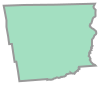

In [28]:
tessellation['geometry'][0]

'Jobs' represents the inflows of a census tract (number of workers commuting to the tract for work). 'Pop' represents the outflows of a census tract (number of workers residing in the tract that leave to work in a different tract).

In [44]:
dsets_grouped['FL'].head()

,Id,Jobs,Pop
0,36071014400,25,0
1,12071010305,482,1628
2,12011110402,945,2337
3,12011110403,329,1853
4,12011110404,354,2120


In [39]:
flows_ex = skmob.utils.constants.NY_FLOWS_2011 #https://raw.githubusercontent.com/scikit-mobility/scikit-mobility/master/examples/NY_commuting_flows_2011.csv
flows_ex = pd.read_csv(flows_ex)

In [40]:
flows_ex.head()

,flow,origin,destination
0,121606,36001,36001
1,5,36001,36005
2,29,36001,36007
3,11,36001,36017
4,30,36001,36019


In [41]:
datasets['FL'].head()

,Otract,Dtract,EST
0,12001000201,12001000201,405.0
1,12001000201,12001000202,40.0
2,12001000201,12001000301,20.0
3,12001000201,12001000400,225.0
4,12001000201,12001000500,35.0
